# `SOX4` Binding to `RBFOX2`

## Purpose: 

Take `RBFOX2` 1-line `BED` files for 
* `hg38`
* `mm10`

and extend the `RBFOX2` region by 1000 base pairs and upstream and downstream. 

Intersect these extended `RBFOX2` regions with: 

* ReMap 2022 `SOX4` 
* ChIP-Atlas `SOX4`

while making sure to match species. 

## Packages and Options

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, os 

## Separate RBFOX2 Files and Database Files 

In [2]:
rbfox2_files = [file for file in glob.glob("../inputs/*.bed") if "rbfox2.bed" in file]
database_files = [file for file in glob.glob("../inputs/*.bed") if not "rbfox2.bed" in file]

rbfox2_files
database_files

['../inputs/mm10_rbfox2.bed', '../inputs/hg38_rbfox2.bed']

['../inputs/remap2022_SOX4_all_macs2_hg38_v1_0.bed',
 '../inputs/mm10_Oth.ALL.05.Sox4.AllCell.bed',
 '../inputs/remap2022_SOX4_all_macs2_mm10_v1_0.bed',
 '../inputs/hg38_Oth.ALL.05.SOX4.AllCell.bed']

## RBFOX2 Gene Coordinates 

### Human

Using the highlighted isoform coordinates for this analysis. 

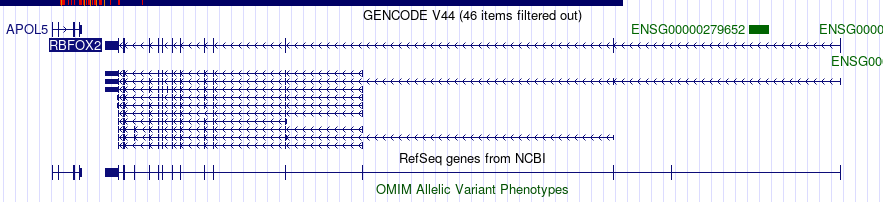

### Mouse

Using the highlighted isoform coordinates for this analysis. 

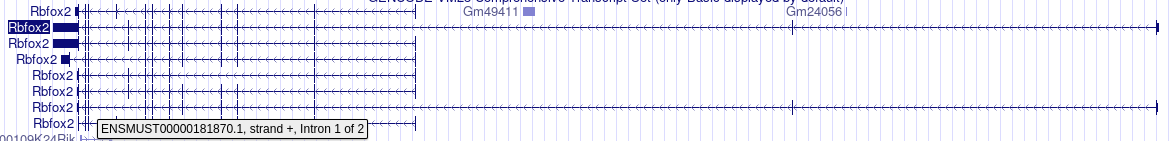

## Bedtools Window

Extend `RBFOX2` window and then intersect with data elsewhere. 

In [3]:
all_species = ["hg38", "mm10"]

# for each species
for species in all_species: 
    
    # get rbfox2 file 
    rbfox2_file = glob.glob(
        "../inputs/*{}*rbfox2*".format(species)
    )[0]
    
    # get database files
    database_files = glob.glob(
        "../inputs/*remap*{}*".format(species)
    ) + glob.glob(
        "../inputs/*{}*Oth.ALL*".format(species)
    )
    
    # for each database file 
    for file in database_files: 
        
        # get database name 
        database_output_tag = ""
        if "remap" in file: 
            database_output_tag="remap"
        elif "Oth.ALL" in file: 
            database_output_tag = "chipAtlas"
        
        # create output file 
        output_file = "{}_{}.bed".format(species, database_output_tag)
        
        # window bedtools with extended rbfox2 window of 1000 bp around rbfox2 
        ! /home/jve4pt/.yogi_utils/bedtools-2.30.1/bedtools2/bin/bedtools window -a {rbfox2_file} -b {file} -w 1000 > {output_file}

## Inspect Results

In [4]:
for file in glob.glob("*.bed"): 
    
    file
    
    try:
        pd.read_csv(file, sep="\t", header=None)
    except: 
        "{} is empty".format(file)


'mm10_chipAtlas.bed'

,0,1,2,3,4,5,6,7,8,9,10,11
0,chr15,77078990,77306928,chr15,77150402,77150696,"ID=SRX4802721;Name=Sox4%20(@%20Neural%20Stem%20Cells);Title=GSM3417934:%20NSCSox4%3B%20Mus%20musculus%3B%20ChIP-Seq;Cell%20group=Neural;<br>source_name=Emrbyonic%20neural%20stem%20cells;strain=CD-1;age=E14.5;cell%20type=embryonic%20neural%20stem%20cells;chip%20antibody=rabbit%20anti-SOX4%20(Diagenode,%20CS-129-100);",125,.,77150402,77150696,"0,127,255"
1,chr15,77078990,77306928,chr15,77150463,77150694,ID=SRX4791026;Name=Sox4%20(@%20Keratinocytes);Title=GSM3414997:%20Sox4%20ChIP-seq%202%3B%20Mus%20musculus%3B%20ChIP-Seq;Cell%20group=Epidermis;<br>source_name=keratinocytes%20transduced%20with%20Sox4-Flag%20lentivirus;strain%20background=mixed%20129SvEx:C57BL/6;cell%20type=primary%20keratinocytes;genotype/variation=Krt14-Cre%3BSox11fl/fl%3BSox4fl/fl;chip%20antibody=mouse%20anti-FLAG%20antibody%20(Sigma);,208,.,77150463,77150694,"0,212,255"
2,chr15,77078990,77306928,chr15,77153025,77153317,"ID=SRX4802721;Name=Sox4%20(@%20Neural%20Stem%20Cells);Title=GSM3417934:%20NSCSox4%3B%20Mus%20musculus%3B%20ChIP-Seq;Cell%20group=Neural;<br>source_name=Emrbyonic%20neural%20stem%20cells;strain=CD-1;age=E14.5;cell%20type=embryonic%20neural%20stem%20cells;chip%20antibody=rabbit%20anti-SOX4%20(Diagenode,%20CS-129-100);",145,.,77153025,77153317,"0,147,255"
3,chr15,77078990,77306928,chr15,77306628,77306972,"ID=SRX4802721;Name=Sox4%20(@%20Neural%20Stem%20Cells);Title=GSM3417934:%20NSCSox4%3B%20Mus%20musculus%3B%20ChIP-Seq;Cell%20group=Neural;<br>source_name=Emrbyonic%20neural%20stem%20cells;strain=CD-1;age=E14.5;cell%20type=embryonic%20neural%20stem%20cells;chip%20antibody=rabbit%20anti-SOX4%20(Diagenode,%20CS-129-100);",216,.,77306628,77306972,"0,220,255"


'hg38_chipAtlas.bed'

'hg38_chipAtlas.bed is empty'

'mm10_remap.bed'

,0,1,2,3,4,5,6,7,8,9,10,11
0,chr15,77078990,77306928,chr15,77147928,77148285,GSE100689.SOX4.CD34,5.59136,.,77148175,77148176,"151,217,175"
1,chr15,77078990,77306928,chr15,77150218,77150757,GSE120894.SOX4.ENSC,12.11404,.,77150625,77150626,"151,217,175"
2,chr15,77078990,77306928,chr15,77152893,77153556,GSE120894.SOX4.ENSC,13.71399,.,77153106,77153107,"151,217,175"
3,chr15,77078990,77306928,chr15,77306668,77306985,GSE120894.SOX4.ENSC,9.09272,.,77306805,77306806,"151,217,175"


'hg38_remap.bed'

,0,1,2,3,4,5,6,7,8,9,10,11
0,chr22,35738736,36028824,chr22,35777591,35777951,GSE104760.SOX4.MDA-MB-231_TGFb,5.76873,.,35777761,35777762,"151,217,175"
1,chr22,35738736,36028824,chr22,35784075,35784343,GSE104760.SOX4.MDA-MB-231_TGFb,3.54968,.,35784266,35784267,"151,217,175"
2,chr22,35738736,36028824,chr22,35836034,35836728,GSE104760.SOX4.HCC1954,7.48276,.,35836424,35836425,"151,217,175"
3,chr22,35738736,36028824,chr22,35836263,35836480,GSE104760.SOX4.MDA-MB-231_TGFb,3.42554,.,35836405,35836406,"151,217,175"
4,chr22,35738736,36028824,chr22,35892308,35892619,GSE104760.SOX4.MDA-MB-231,4.38510,.,35892440,35892441,"151,217,175"
5,chr22,35738736,36028824,chr22,35910280,35910480,GSE104760.SOX4.MDA-MB-231,2.40602,.,35910418,35910419,"151,217,175"
6,chr22,35738736,36028824,chr22,35914578,35914786,GSE104760.SOX4.MDA-MB-231,4.54786,.,35914628,35914629,"151,217,175"
7,chr22,35738736,36028824,chr22,35921883,35922129,GSE104760.SOX4.MDA-MB-231_TGFb,5.25175,.,35921999,35922000,"151,217,175"
8,chr22,35738736,36028824,chr22,36010993,36011228,GSE104760.SOX4.MDA-MB-231_TGFb,6.23206,.,36011087,36011088,"151,217,175"
9,chr22,35738736,36028824,chr22,36028088,36028341,GSE75910.SOX4.MRC-5_1DPT,3.46594,.,36028237,36028238,"151,217,175"


In [5]:
for file in glob.glob("*.bed"): 
    os.remove(file)